In [73]:
import numpy as np
import nibabel as nib
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from monai.transforms import Compose, EnsureChannelFirst, Resize, ScaleIntensityRange
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import mean_squared_error as compare_mse
import pymedphys
import SimpleITK as sitk
import glob
import os

from monai.transforms import Compose, Resize, ScaleIntensityRange
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from monai.visualize import matshow3d

In [ ]:
class CompareMedicalImages:
    @staticmethod
    def load_volume(path, do_preprocessing=False, spatial_size=(1,400,400,32), win_lev=60, win_wid=400):
        """
        Load NIfTI volume and optionally preprocess:
        - Resize to spatial_size
        - Apply windowing (ScaleIntensityRange)
        Returns numpy.ndarray (H,W,D)
        """
        img = nib.load(path)
        data = img.get_fdata().astype(np.float32)

        if do_preprocessing:
            # Dodaj wymiar kanału (1,H,W,D)
            data = np.expand_dims(data, axis=0)

            transforms = Compose([
                Resize(spatial_size=spatial_size, mode="area"),
                ScaleIntensityRange(
                    a_min=win_lev - (win_wid / 2),
                    a_max=win_lev + (win_wid / 2),
                    b_min=0.0,
                    b_max=1.0,
                    clip=True
                ),
            ])

            data = transforms(data)  # (1,H,W,D)
            data = np.squeeze(data, axis=0)  # (H,W,D)

        return data
    
    


## Szybki podgląd przykładowych obrazów (real vs. generated)

In [87]:
generated_patient ="/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_7.nii.gz"
generated_patient2="/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_2.nii.gz"
generated_patient_img = nib.load(generated_patient)
generated_patient_data = generated_patient_img.get_fdata()


generated_patient_img2 = nib.load(generated_patient2)
generated_patient_data2 = generated_patient_img2.get_fdata()

real_patient ="/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/PATIENT_NAME_088.nii.gz"
real_patient2 ="/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/PATIENT_NAME_088.nii.gz"
real_patient_img = nib.load(real_patient)
real_patient_data = real_patient_img.get_fdata()
real_patient_data_preprocessed = CompareMedicalImages.load_volume(real_patient, do_preprocessing=True, spatial_size=(512,512,32), win_lev=60, win_wid=400)


real_patient_img2 = nib.load(real_patient2)
real_patient_data2 = real_patient_img2.get_fdata()
real_patient_data_preprocessed2 = CompareMedicalImages.load_volume(real_patient2, do_preprocessing=True, spatial_size=(512,512,32), win_lev=60, win_wid=400)
#real_patient_img = nib.load(real_patient)
#real_patient_data = real_patient_img.get_fdata()

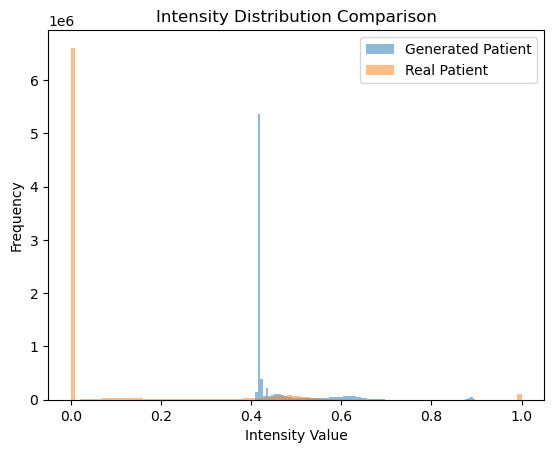

In [88]:
plt.hist(generated_patient_data.ravel(), bins=100, alpha=0.5, label='Generated Patient')
plt.hist(real_patient_data_preprocessed.ravel(), bins=100, alpha=0.5, label='Real Patient')
plt.title('Intensity Distribution Comparison')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.legend()

In [89]:
from scipy.stats import wasserstein_distance

def histogram_wasserstein(vol1, vol2, num_bins=100, range=None):
    """
    Compute 1D histogram Wasserstein distance between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        Volumes (H, W, D)
    num_bins : int
        Number of histogram bins
    range : tuple or None
        Range of intensities

    Returns
    -------
    wd : float
        Wasserstein distance between the histograms
    """
    v1 = vol1.ravel()
    v2 = vol2.ravel()

    # automatic range if None
    if range is None:
        min_val = min(v1.min(), v2.min())
        max_val = max(v1.max(), v2.max())
        range = (min_val, max_val)

    hist1, bin_edges = np.histogram(v1, bins=num_bins, range=range, density=True)
    hist2, _ = np.histogram(v2, bins=num_bins, range=range, density=True)

    # bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    wd = wasserstein_distance(bin_centers, bin_centers, u_weights=hist1, v_weights=hist2)
    return wd

In [6]:
psnr_score = compare_psnr(generated_patient_data, generated_patient_data2, data_range=generated_patient_data2.max() - generated_patient_data2.min())
print(psnr_score)
wd = histogram_wasserstein(generated_patient_data.ravel(), generated_patient_data2.ravel())
print(wd)

13.021522022794263
0.10436649738310769


In [7]:
psnr_score = compare_psnr(real_patient_data_preprocessed, generated_patient_data, data_range=generated_patient_data.max() - generated_patient_data.min())
print(psnr_score)
wd = histogram_wasserstein(real_patient_data_preprocessed.ravel(), generated_patient_data.ravel())
print(wd)

2.356576387891326
0.42911746993592204


In [12]:
psnr_score = compare_psnr(real_patient_data_preprocessed, real_patient_data_preprocessed2, data_range=real_patient_data_preprocessed2.max() - real_patient_data_preprocessed2.min())
print(psnr_score)
wd = histogram_wasserstein(real_patient_data_preprocessed.ravel(), real_patient_data_preprocessed2.ravel())
print(wd)

17.783757956184918
0.016599105339745283


In [7]:
psnr_score

12.275158701007612

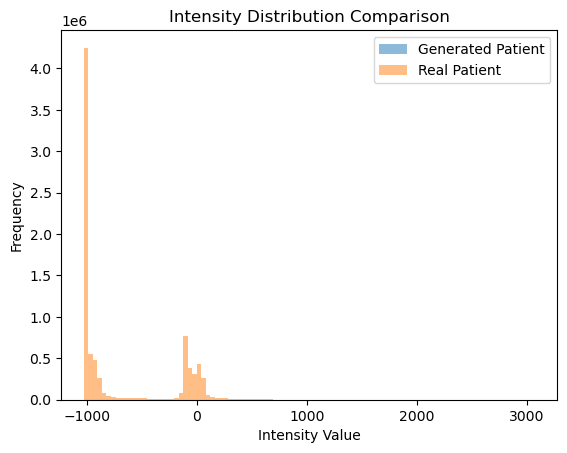

In [5]:
plt.hist(generated_patient_data.ravel(), bins=100, alpha=0.5, label='Generated Patient')
plt.hist(real_patient_data.ravel(), bins=100, alpha=0.5, label='Real Patient')
plt.title('Intensity Distribution Comparison')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.legend()

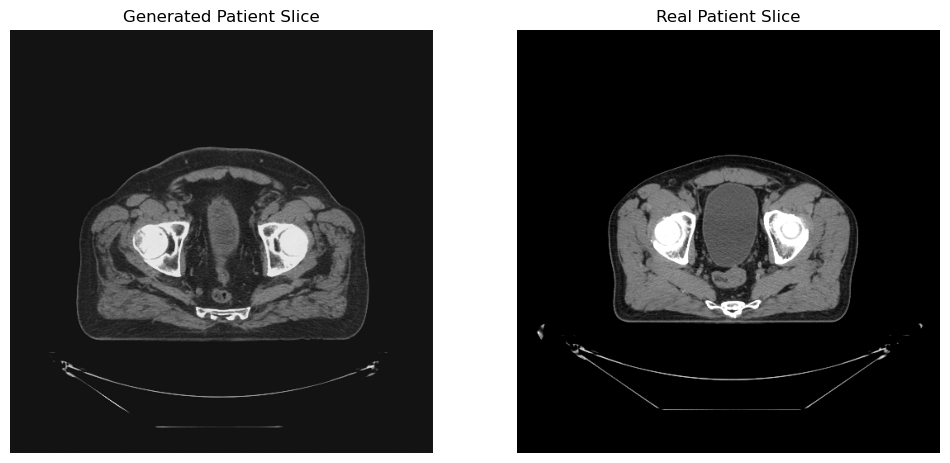

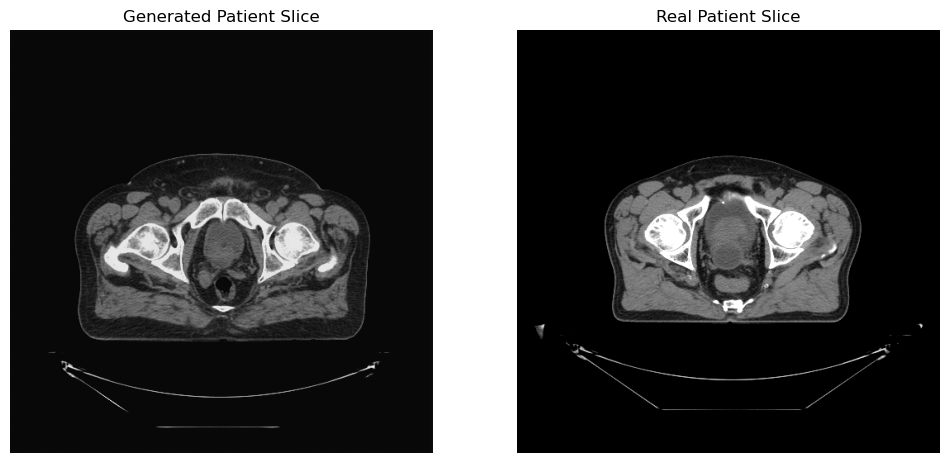

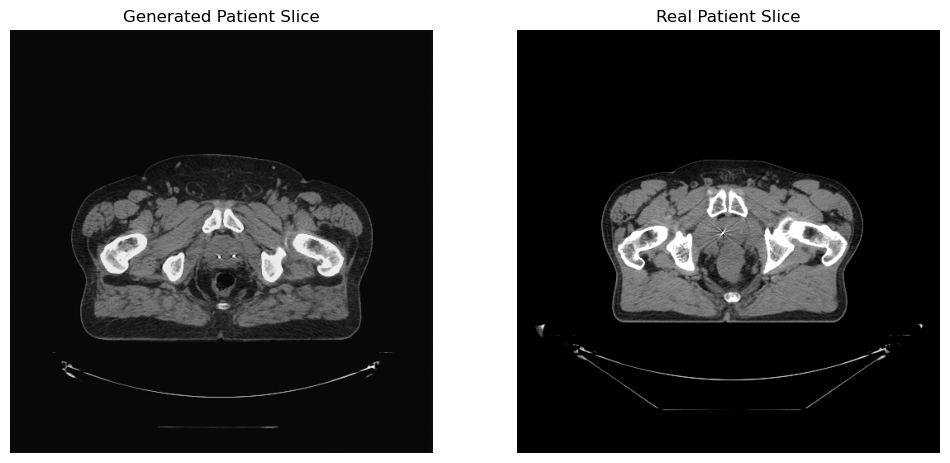

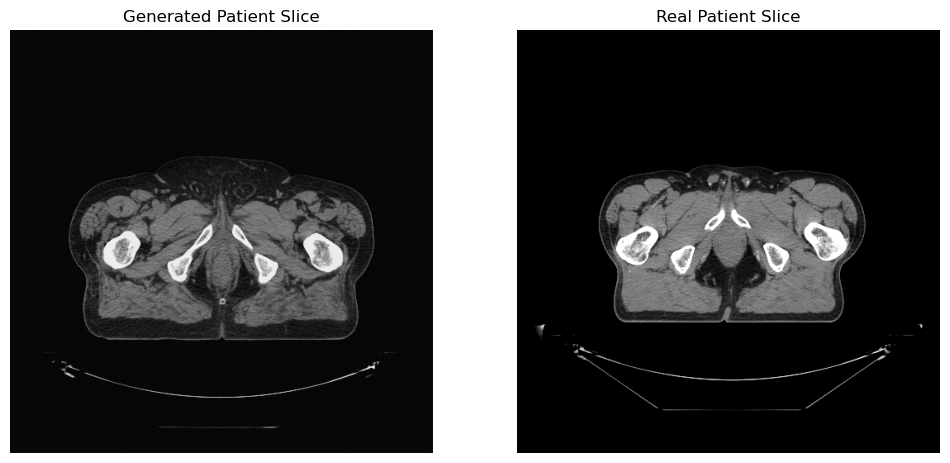

In [90]:
for i in range(0,32,8):
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(generated_patient_data[:, :, i], cmap='gray')
    ax1.set_title('Generated Patient Slice')
    ax1.axis('off')
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(real_patient_data_preprocessed[:, :, i], cmap='gray')
    ax2.set_title('Real Patient Slice')
    ax2.axis('off')
    
    


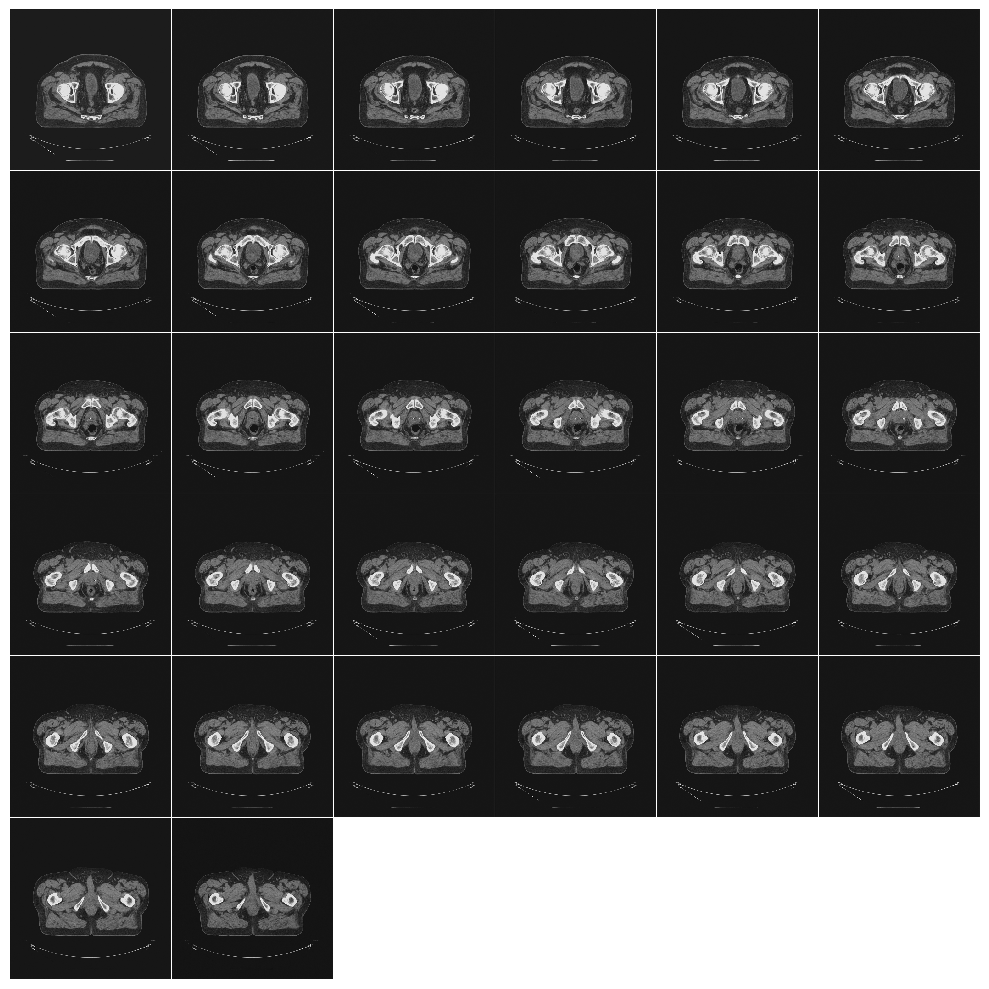

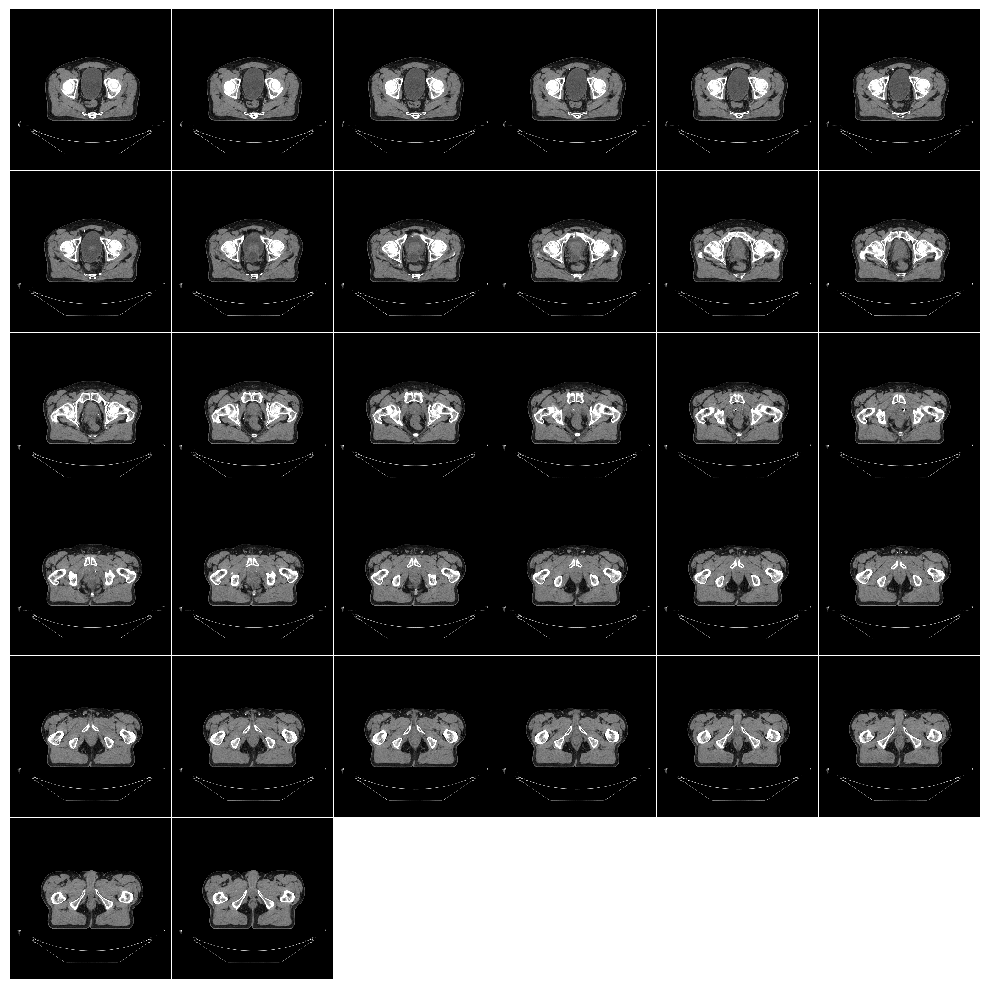

In [91]:
import matplotlib.pyplot as plt
from monai.visualize import matshow3d

# Generated
fig1 = plt.figure(figsize=(12, 6))
matshow3d(
    volume=generated_patient_data,
    fig=fig1,
    every_n=1,
    frame_dim=-1,
    cmap="gray"
)
#fig1.suptitle("Generated Volume – All Slices", fontsize=14)
plt.tight_layout()
plt.show()


# Real
fig2 = plt.figure(figsize=(12, 6))
matshow3d(
    volume=real_patient_data_preprocessed,
    fig=fig2,
    every_n=1,
    frame_dim=-1,
    cmap="gray"
)
#fig2.suptitle("Real Volume – All Slices", fontsize=14)
plt.tight_layout()
plt.show()

# Analiza porównawcza

Funkcje pomocnicze

In [59]:
import numpy as np
import glob
import nibabel as nib
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from monai.transforms import Compose, EnsureChannelFirst, Resize, ScaleIntensityRange
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import mean_squared_error as compare_mse
import pymedphys
import SimpleITK as sitk
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.transform import pyramid_reduce
from monai.metrics import MultiScaleSSIMMetric
from scipy.stats import wasserstein_distance

def histogram_wasserstein(vol1, vol2, num_bins=100, range=None):
    """
    Compute 1D histogram Wasserstein distance between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        Volumes (H, W, D)
    num_bins : int
        Number of histogram bins
    range : tuple or None
        Range of intensities

    Returns
    -------
    wd : float
        Wasserstein distance between the histograms
    """
    v1 = vol1.ravel()
    v2 = vol2.ravel()

    # automatic range if None
    if range is None:
        min_val = min(v1.min(), v2.min())
        max_val = max(v1.max(), v2.max())
        range = (min_val, max_val)

    hist1, bin_edges = np.histogram(v1, bins=num_bins, range=range, density=True)
    hist2, _ = np.histogram(v2, bins=num_bins, range=range, density=True)

    # bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    wd = wasserstein_distance(bin_centers, bin_centers, u_weights=hist1, v_weights=hist2)
    return wd

def compute_ms_ssim(
    vol1,
    vol2,
    mode="2d",          # "2d" | "3d"
    slice_axis=2,       # D axis for slice-wise MS-SSIM
    data_range=None,
    device="cpu",
):
    """
    MS-SSIM for medical volumes.

    Input shape: (H, W, D)

    mode="2d"  -> slice-wise MS-SSIM
    mode="3d"  -> full 3D MS-SSIM (limited scales)
    """

    # --------------------
    # to torch
    # --------------------
    def to_tensor(x):
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        return x.float()

    vol1 = to_tensor(vol1).to(device)
    vol2 = to_tensor(vol2).to(device)

    if vol1.ndim != 3:
        raise ValueError("Expected input shape (H, W, D)")

    # add batch + channel: (B, C, H, W, D)
    vol1 = vol1.unsqueeze(0).unsqueeze(0)
    vol2 = vol2.unsqueeze(0).unsqueeze(0)

    # --------------------
    # normalization
    # --------------------
    if data_range is None:
        min_val = torch.min(vol1.min(), vol2.min())
        max_val = torch.max(vol1.max(), vol2.max())
        data_range = max_val - min_val + 1e-6

    vol1 = (vol1 - min_val) / data_range
    vol2 = (vol2 - min_val) / data_range

    # ============================
    # 2D SLICE-WISE MS-SSIM
    # ============================
    if mode == "2d":
        metric = MultiScaleSSIMMetric(
            spatial_dims=2,
            data_range=1.0,
        )

        scores = []
        num_slices = vol1.shape[2 + slice_axis]  # H/W/D

        for i in range(num_slices):
            sl1 = torch.index_select(
                vol1, 2 + slice_axis, torch.tensor(i, device=device)
            ).squeeze(2 + slice_axis)

            sl2 = torch.index_select(
                vol2, 2 + slice_axis, torch.tensor(i, device=device)
            ).squeeze(2 + slice_axis)

            # skip flat slices
            if torch.std(sl1) < 1e-6 or torch.std(sl2) < 1e-6:
                continue

            score = metric(sl1, sl2)
            scores.append(score.item())

        if len(scores) == 0:
            return float("nan"), float("nan")

        return float(np.mean(scores)), float(np.std(scores))

    # ============================
    # 3D MS-SSIM
    # ============================
    elif mode == "3d":
        metric = MultiScaleSSIMMetric(
            spatial_dims=3,
            data_range=1.0,
            kernel_size=7,
            weights=(0.5, 0.5),  # 2 skale
        )

        score = metric(vol1, vol2)
        return float(score.item()), None

    else:
        raise ValueError("mode must be '2d' or '3d'")


def mattes_mutual_information(
    reference: np.ndarray,
    evaluation: np.ndarray,
    num_bins: int = 50,
) -> float:
    """
    Compute Mattes Mutual Information using SimpleITK (robust API).

    Parameters
    ----------
    reference : np.ndarray
        Reference volume (H, W, D)
    evaluation : np.ndarray
        Evaluated volume (H, W, D)
    num_bins : int
        Number of histogram bins

    Returns
    -------
    mi : float
        Mattes Mutual Information
    """

    # SimpleITK expects (Z,Y,X)
    ref_img = sitk.GetImageFromArray(reference.astype(np.float32))
    eval_img = sitk.GetImageFromArray(evaluation.astype(np.float32))

    registration = sitk.ImageRegistrationMethod()

    registration.SetMetricAsMattesMutualInformation(
        numberOfHistogramBins=num_bins
    )

    # Identity transform, no optimization
    registration.SetInterpolator(sitk.sitkLinear)
    registration.SetOptimizerAsGradientDescent(
        learningRate=0.0,
        numberOfIterations=1
    )

    registration.SetInitialTransform(sitk.Transform(), inPlace=False)

    registration.Execute(ref_img, eval_img)
    mi = -registration.GetMetricValue()
    return mi


def dice_coefficient(mask1, mask2, epsilon=1e-6):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)
    intersection = np.sum(mask1 & mask2)
    return (2. * intersection) / (np.sum(mask1) + np.sum(mask2) + epsilon)

def jaccard_index(mask1, mask2, epsilon=1e-6):
    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)
    intersection = np.sum(mask1 & mask2)
    union = np.sum(mask1 | mask2)
    return (intersection + epsilon) / (union + epsilon)


def calculate_gamma_passing_rate(
    reference: np.ndarray,
    evaluation: np.ndarray,
    spacing=(1.0, 1.0, 2.5),   # (sx, sy, sz) mm
    dose_percent_threshold=3.0,
    distance_mm_threshold=3.0,
    lower_percent_dose_cutoff=10.0,
):
    """
    Compute Gamma Passing Rate (3D) using PyMedPhys.

    Parameters
    ----------
    reference : np.ndarray
        Reference volume (D, H, W)
    evaluation : np.ndarray
        Evaluated volume (D, H, W)
    spacing : tuple
        Voxel spacing in mm (sx, sy, sz)
    dose_percent_threshold : float
        Dose difference threshold [%]
    distance_mm_threshold : float
        Distance-to-agreement threshold [mm]
    lower_percent_dose_cutoff : float
        Ignore voxels below this % of max reference dose

    Returns
    -------
    gpr : float
        Gamma Passing Rate in [0,1]
    """

    # PyMedPhys expects axes as physical coordinates
    z = np.arange(reference.shape[0]) * spacing[2]
    y = np.arange(reference.shape[1]) * spacing[1]
    x = np.arange(reference.shape[2]) * spacing[0]

    axes = (z, y, x)

    gamma = pymedphys.gamma(
        axes,
        reference,
        axes,
        evaluation,
        dose_percent_threshold=dose_percent_threshold,
        distance_mm_threshold=distance_mm_threshold,
        lower_percent_dose_cutoff=lower_percent_dose_cutoff,
        interp_fraction=10,
        max_gamma=2.0,
        local_gamma=False,
        ram_available=2**31,
    )

    valid_gamma = gamma[~np.isnan(gamma)]
    pass_ratio = np.sum(valid_gamma <= 1) / len(valid_gamma)
    return pass_ratio


from dataclasses import dataclass
from typing import Optional
import numpy as np

@dataclass
class VolumeInfo:
    path: str
    data: np.ndarray = None
    patient_id: Optional[str] = None
    is_real: bool = True
    source: str = "real"   # np. "real", "diffusion", "gan"


Główna klasa do porównywania

In [60]:
import itertools
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from monai.transforms import Compose, Resize, ScaleIntensityRange
import pandas as pd

class CompareMedicalImages:
    def __init__(
        self,
        volumes: list[VolumeInfo],
        do_preprocessing=True,
        spatial_size=(400, 400, 32),
        win_lev=60,
        win_wid=400,
    ):
        self.do_preprocessing = do_preprocessing
        self.spatial_size = spatial_size
        self.win_lev = win_lev
        self.win_wid = win_wid

        self.volumes: list[VolumeInfo] = []

        for v in volumes:
            if v.is_real:
                data = self.load_volume(
                    v.path,
                    do_preprocessing,
                    spatial_size,
                    win_lev,
                    win_wid,
                )
            else:
                data = self.load_volume(
                    v.path,
                    False,  # no preprocessing for generated (assume already preprocessed)
                    spatial_size,
                    win_lev,
                    win_wid,
                )
            self.volumes.append(
                VolumeInfo(
                    path=v.path,
                    data=data,
                    patient_id=v.patient_id,
                    is_real=v.is_real,
                    source=v.source,
                )
            )

        self.images_metrics_results = []
        
    @staticmethod
    def load_volume(path, do_preprocessing=False, spatial_size=(400,400,32),
                    win_lev=60, win_wid=400):

        img = nib.load(path)
        data = img.get_fdata().astype(np.float32)

        if do_preprocessing:
            data = np.expand_dims(data, axis=0)

            transforms = Compose([
                Resize(spatial_size=spatial_size),
                ScaleIntensityRange(
                    a_min=win_lev - win_wid / 2,
                    a_max=win_lev + win_wid / 2,
                    b_min=0.0,
                    b_max=1.0,
                    clip=True,
                ),
            ])
            data = transforms(data)
            data = np.squeeze(data, axis=0)

        return data
    
    @staticmethod
    def compute_image_metrics_pair(img1, img2):
        mse = compare_mse(img1, img2)
        psnr = compare_psnr(img1, img2, data_range=img2.max() - img2.min())
        mi = mattes_mutual_information(img1, img2)
        ms_ssim = compute_ms_ssim(img1, img2)
        ms_ssim_3d = compute_ms_ssim(img1, img2, mode="3d")
        wd = histogram_wasserstein(img1, img2)

        return {
            "MSE": mse,
            "PSNR": psnr,
            "Mutual-Information": mi,
            "MS-SSIM_mean": ms_ssim[0],
            "MS-SSIM_std": ms_ssim[1],
            "MS-SSIM-3D": ms_ssim_3d[0],
            "Wasserstein-Distance": wd,
        }
        
        
    def results_to_dataframe(self):
        if not self.images_metrics_results:
            raise RuntimeError("Run compute_image_similarity_metrics() first")

        df = pd.DataFrame(self.images_metrics_results)

        # wygodne aliasy
        df["pair_id"] = df["i"].astype(str) + "-" + df["j"].astype(str)

        return df
        
    def compute_image_similarity_metrics(self, skip_comparison_types=[]):
        results = []
        N = len(self.volumes)

        for i in range(N):
            for j in range(i, N):
                v1 = self.volumes[i]
                v2 = self.volumes[j]

                comp_type = self._comparison_type(v1, v2)
                if comp_type in skip_comparison_types:
                    continue

                metrics = self.compute_image_metrics_pair(v1.data, v2.data)

                record = {
                    "i": i,
                    "j": j,
                    # "i_path": v1.path,
                    # "j_path": v2.path,
                    "i_path_short": os.path.basename(v1.path),
                    "j_path_short": os.path.basename(v2.path),
                    "pair": (i, j),
                    "pair_type": "self" if i == j else "cross",
                    "same_patient": v1.patient_id == v2.patient_id,
                    "source_i": v1.source,
                    "source_j": v2.source,
                    "is_real_i": v1.is_real,
                    "is_real_j": v2.is_real,
                    "comparison_type": self._comparison_type(v1, v2),
                }

                record.update(metrics)
                results.append(record)

        self.images_metrics_results = results
        return results
    
    @staticmethod
    def _comparison_type(v1: VolumeInfo, v2: VolumeInfo):
        if v1.is_real and v2.is_real:
            return "real-real"
        if not v1.is_real and not v2.is_real:
            return "gen-gen"
        return "real-gen"
    
    
    def plot_heatmap(
        self,
        metric_name="PSNR",
        show_self=True,
        vmin=None,
        vmax=None,
        annotate=True,
    ):
        n = len(self.volumes)
        mat = np.full((n, n), np.nan)
        
        first_gen = next(
            i for i, v in enumerate(self.volumes) if not v.is_real
        )

        labels = []
        for v in self.volumes:
            prefix = "R" if v.is_real else "G"
            labels.append(f"{prefix}_{v.patient_id}")
            
        for r in self.images_metrics_results:
            i, j = r["i"], r["j"]

            if not show_self and r["pair_type"] == "self":
                continue

            val = r.get(metric_name, np.nan)
            mat[i, j] = val
            mat[j, i] = val

        if metric_name.upper() == "PSNR":
            np.fill_diagonal(mat, np.nan)
            vmin = np.nanpercentile(mat, 5) if vmin is None else vmin
            vmax = np.nanpercentile(mat, 95) if vmax is None else vmax
        # else:
        #     vmin = 0.0 if vmin is None else vmin
        #     vmax = 1.0 if vmax is None else vmax

        mask = np.isnan(mat)

        plt.figure(figsize=(9, 7))
        ax = sns.heatmap(
            mat,
            mask=mask,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            annot=annotate,
            fmt=".2f",
            square=True,
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={"label": metric_name},
        )
        for tick, v in zip(ax.get_xticklabels(), self.volumes):
            tick.set_color("green" if v.is_real else "orange")

        for tick, v in zip(ax.get_yticklabels(), self.volumes):
            tick.set_color("green" if v.is_real else "orange")
            
        plt.axhline(first_gen, color="white", linewidth=2)
        plt.axvline(first_gen, color="white", linewidth=2)
        plt.title(f"{metric_name} heatmap")
        plt.tight_layout()
        plt.show()
        
        
        
    def plot_metric_boxplot(
        self,
        metric_name="PSNR",
        groupby="comparison_type",
        drop_self=True,
        figsize=(7,5),
    ):
        df = self.results_to_dataframe()

        if drop_self:
            df = df[df["pair_type"] != "self"]

        plt.figure(figsize=figsize)
        sns.boxplot(
            data=df,
            x=groupby,
            y=metric_name,
        )
        sns.stripplot(
            data=df,
            x=groupby,
            y=metric_name,
            color="black",
            size=3,
            alpha=0.4,
        )

        plt.title(f"{metric_name} by {groupby}")
        plt.tight_layout()
        plt.show()
        
        
    def plot_metric_boxplot(
        self,
        metric_name="PSNR",
        groupby="comparison_type",
        drop_self=True,
        figsize=(7, 5),
        ylim=None,          # <-- NOWE
    ):
        df = self.results_to_dataframe()

        if drop_self:
            df = df[df["pair_type"] != "self"]

        plt.figure(figsize=figsize)
        sns.boxplot(
            data=df,
            x=groupby,
            y=metric_name,
        )
        sns.stripplot(
            data=df,
            x=groupby,
            y=metric_name,
            color="black",
            size=3,
            alpha=0.4,
        )

        if ylim is not None:
            plt.ylim(ylim)   # np. (0, 50)

        plt.title(f"{metric_name} by Comparison Type")
        plt.tight_layout()
        plt.show()


    def find_suspicious_generated(
        self,
        psnr_thresh=35,
        ssim_thresh=0.95,
    ):
        df = self.results_to_dataframe()

        df = df[
            (df["comparison_type"] == "real-gen") &
            (df["PSNR"] > psnr_thresh) &
            (df["MS-SSIM_mean"] > ssim_thresh)
        ]

        return df.sort_values("PSNR", ascending=False)
    
    
    def plot_pair_plots_hist(self, metric_name=None):
        n = len(self.volumes)
        fig, axes = plt.subplots(n, n, figsize=(3.5 * n, 3.5 * n))

        # --- kolory ---
        color_real = "tab:green"
        color_gen = "tab:orange"
        color_mix = "tab:purple"

        for i in range(n):
            for j in range(n):
                ax = axes[i, j]

                vi = self.volumes[i]
                vj = self.volumes[j]

                img_i = self.volumes[i].data.ravel()
                img_j = self.volumes[j].data.ravel()

                # ======================
                # DIAGONAL: histogram
                # ======================
                if i == j:
                    c = color_real if vi.is_real else color_gen
                    ax.hist(img_i, bins=50, color=c, alpha=0.8)
                    ax.set_title(
                        f"{'R' if vi.is_real else 'G'}_{vi.patient_id}",
                        fontsize=9,
                    )

                # ======================
                # OFF-DIAGONAL: scatter
                # ======================
                else:
                    if vi.is_real and vj.is_real:
                        c = color_real
                    elif (not vi.is_real) and (not vj.is_real):
                        c = color_gen
                    else:
                        c = color_mix

                    ax.scatter(
                        img_i,
                        img_j,
                        s=1,
                        alpha=0.05,
                        color=c,
                    )

                    # opcjonalnie: metryka w tytule
                    if metric_name is not None:
                        rec = next(
                            r for r in self.images_metrics_results
                            if r["pair"] in [(i, j), (j, i)]
                        )
                        val = rec.get(metric_name, None)
                        if val is not None:
                            ax.set_title(f"{metric_name}={val:.2f}", fontsize=7)

                ax.set_xticks([])
                ax.set_yticks([])

        # ======================
        # LEGENDA
        # ======================
        handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=color_real, label='Real–Real', markersize=8),
            plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=color_gen, label='Gen–Gen', markersize=8),
            plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=color_mix, label='Real–Gen', markersize=8),
        ]

        fig.legend(
            handles=handles,
            loc="upper center",
            ncol=3,
            fontsize=10,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()



/opt/anaconda/envs/med/lib/python3.10/site-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


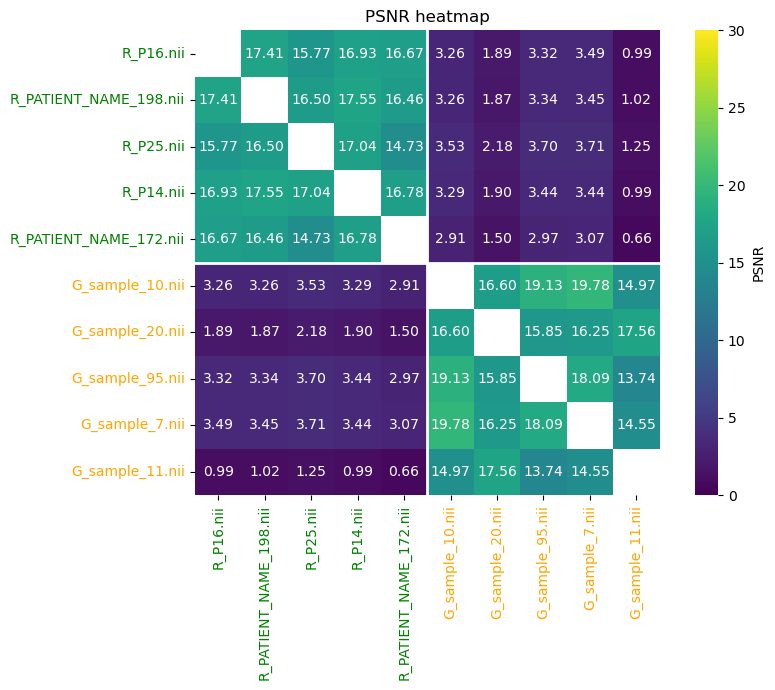

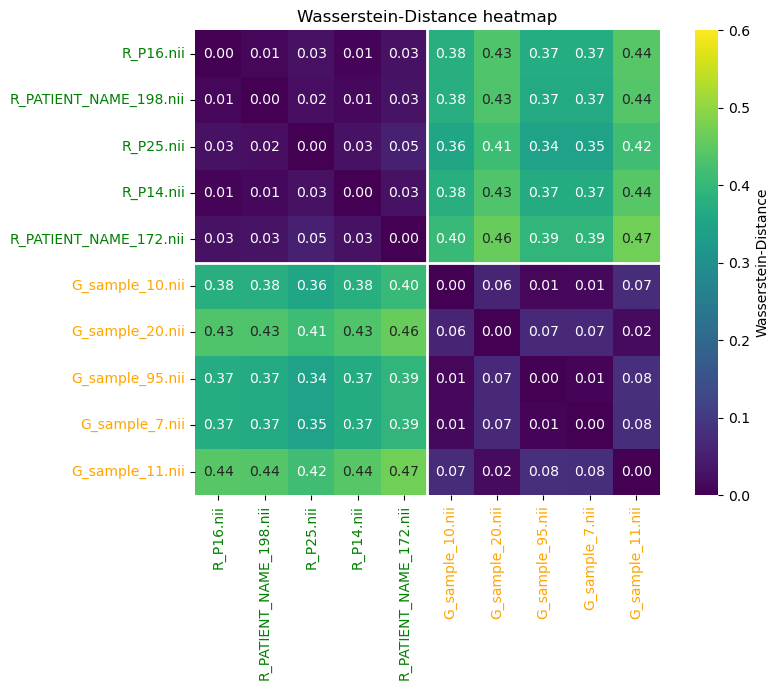

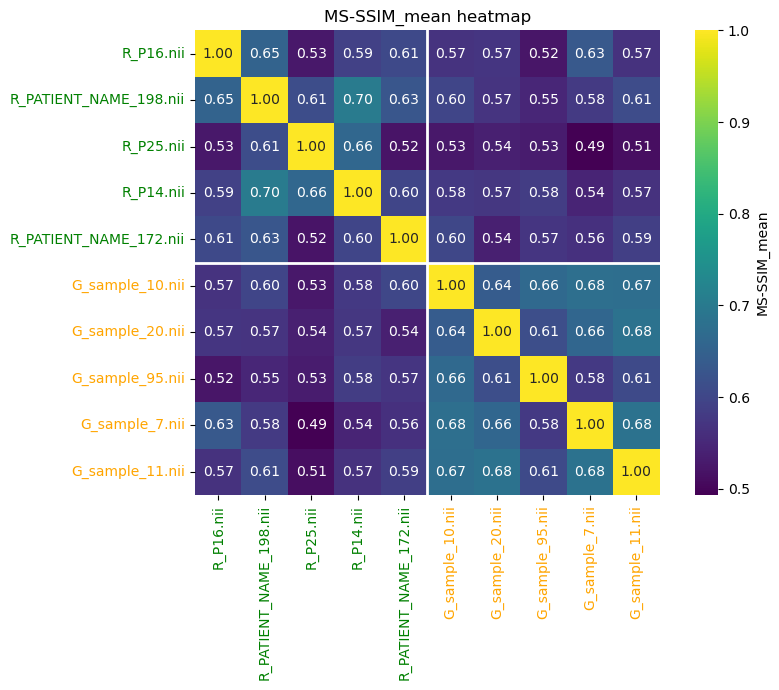

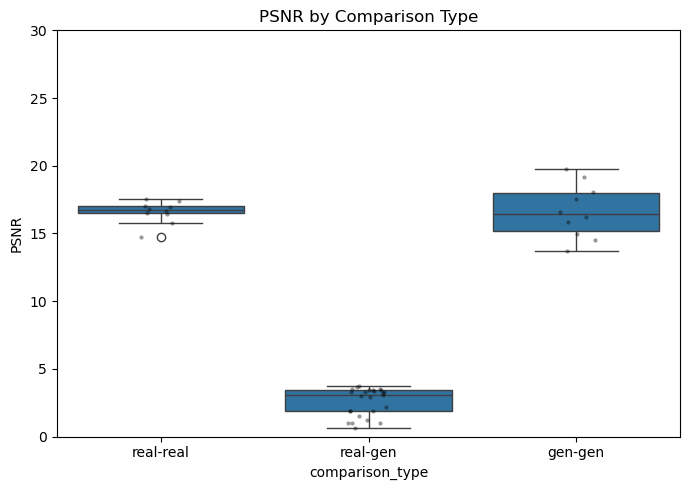

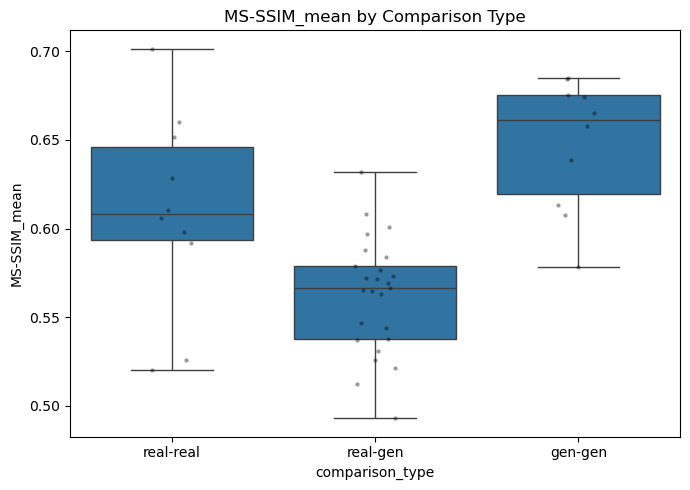

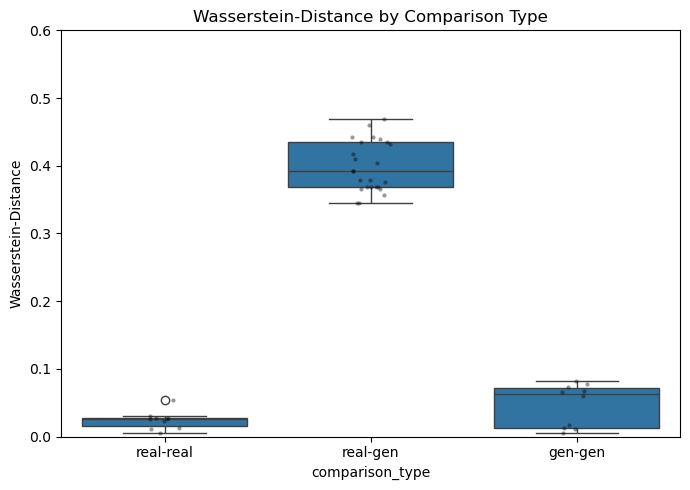

In [68]:
from pathlib import Path
import random


real_paths = sorted(
    glob.glob(
        "/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/*.nii.gz"
    )
)

#good ones
gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_10.nii.gz", 
             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_20.nii.gz",
             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_95.nii.gz",
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_7.nii.gz",    
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_11.nii.gz"]
            # "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_13.nii.gz",
            # "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_14.nii.gz"]

# #bad ones
# gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_3.nii.gz", 
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_4.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_5.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_9.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_12.nii.gz"
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_15.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_10.nii.gz"]

# gen_paths = sorted(
#     glob.glob(
#         "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_*.nii.gz"
#     )
# )

real_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=True,
    )
    for p in real_paths
]

gen_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=False,
    )
    for p in gen_paths
]

#volumes = real_volumes[0:2] + gen_volumes[0:2]
volumes = random.sample(real_volumes, 5) +  gen_volumes
#volumes = real_volumes[0:5] +  gen_volumes

compare_imgs = CompareMedicalImages(volumes, do_preprocessing=True, 
                                    spatial_size=(512, 512, 32),
                                    win_lev=60,
                                    win_wid=400,)
compare_imgs.compute_image_similarity_metrics()
compare_imgs.plot_heatmap("PSNR", vmin=0, vmax=30)
compare_imgs.plot_heatmap("Wasserstein-Distance", vmin=0, vmax=0.6)
compare_imgs.plot_heatmap("MS-SSIM_mean")
#compare_imgs.plot_pair_plots_hist()


compare_imgs.plot_metric_boxplot(
    metric_name="PSNR",
    groupby="comparison_type",
    ylim=(0, 30),
)

compare_imgs.plot_metric_boxplot(
    metric_name="MS-SSIM_mean",
    groupby="comparison_type",
)
compare_imgs.plot_metric_boxplot(
    metric_name="Wasserstein-Distance",
    groupby="comparison_type",
    ylim=(0, 0.6),
)


#compare_imgs.results_to_dataframe().to_csv("image_similarity_metrics_test.csv", index=False)


# BAD ONES - typu noisy

/opt/anaconda/envs/med/lib/python3.10/site-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


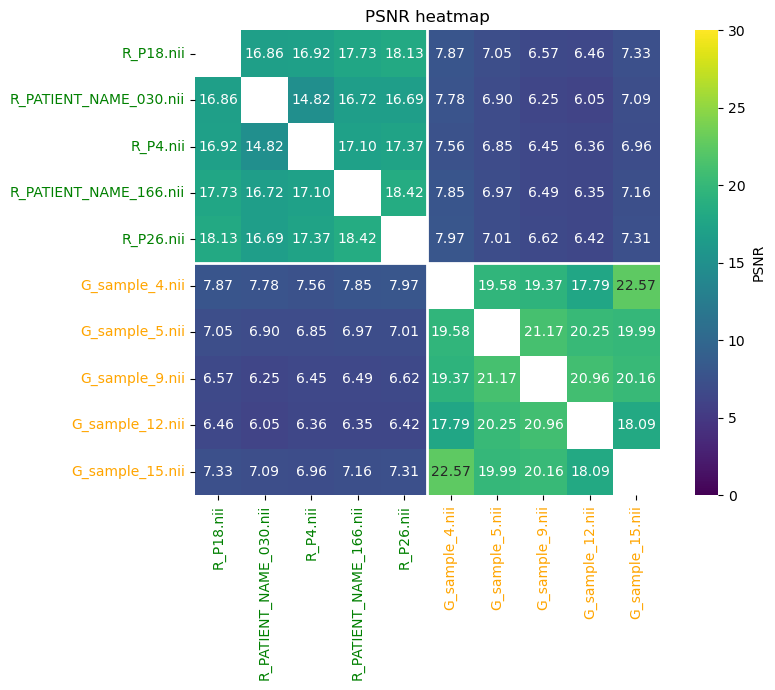

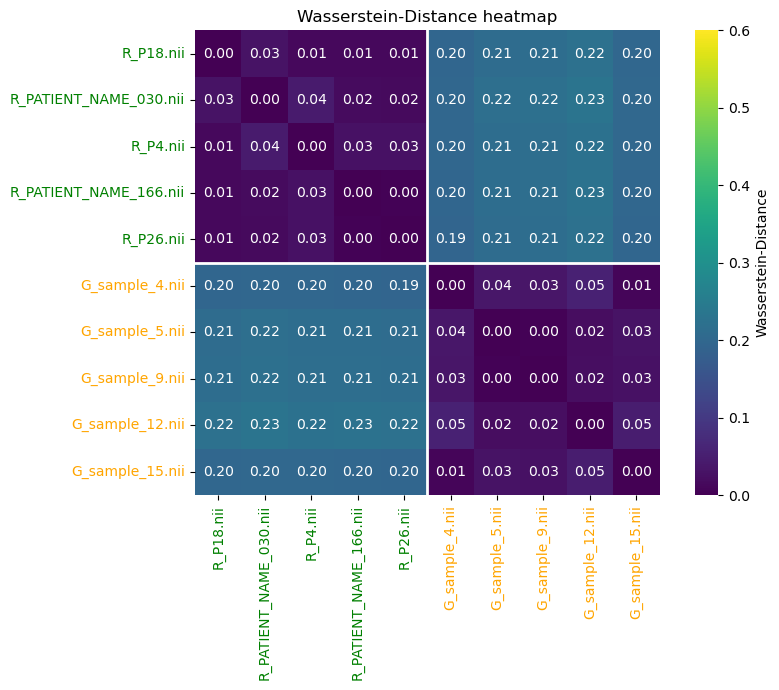

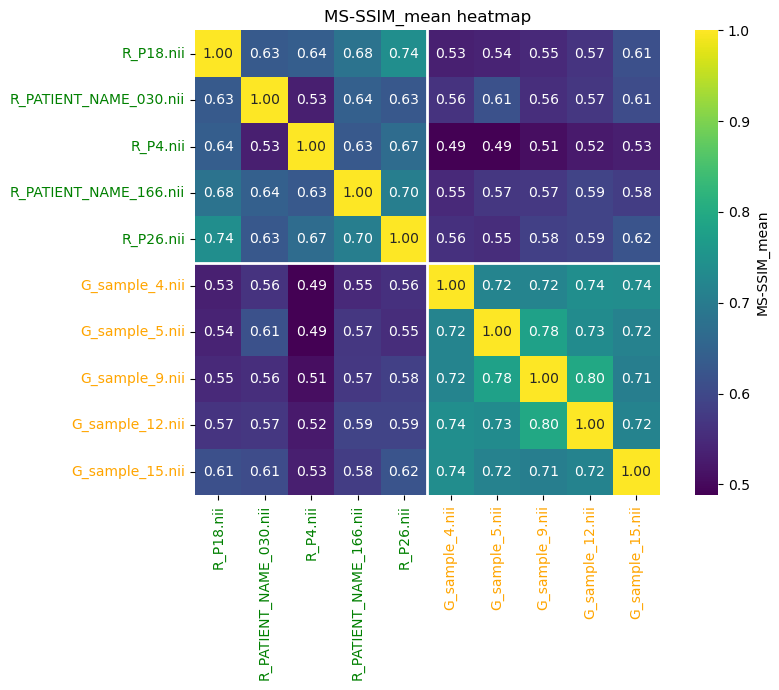

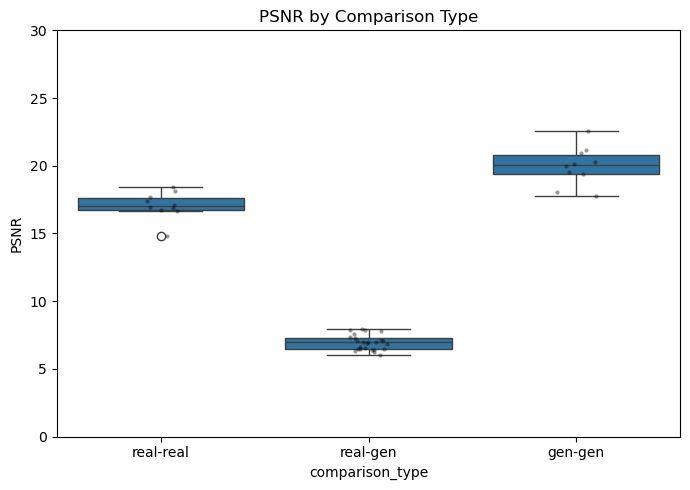

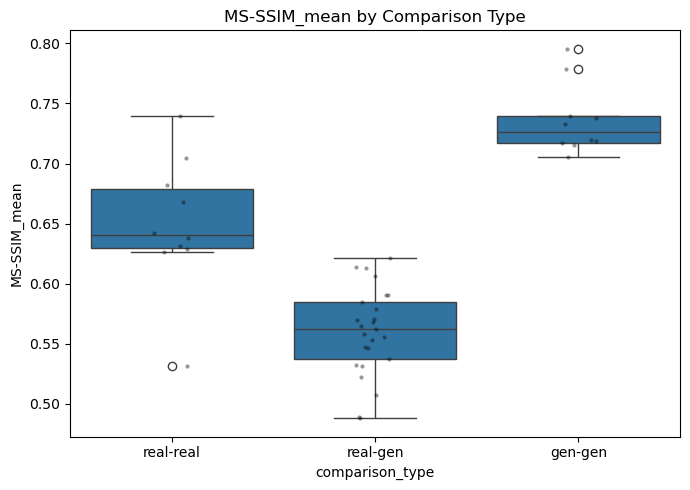

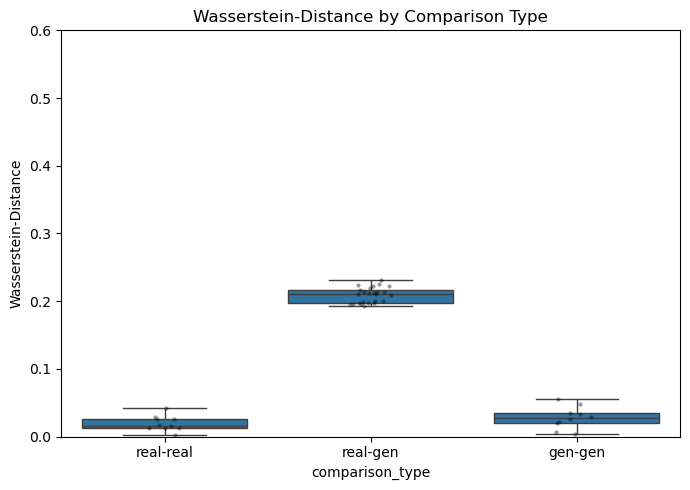

In [69]:
from pathlib import Path
import random


real_paths = sorted(
    glob.glob(
        "/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/*.nii.gz"
    )
)

# #good ones
# gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_10.nii.gz", 
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_20.nii.gz",
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_95.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_7.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_11.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_13.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_14.nii.gz"]

#bad ones
gen_paths = [
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_4.nii.gz",    
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_5.nii.gz",
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_9.nii.gz",
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_12.nii.gz",
            "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_15.nii.gz",
            ]

# gen_paths = sorted(
#     glob.glob(
#         "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_*.nii.gz"
#     )
# )

real_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=True,
    )
    for p in real_paths
]

gen_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=False,
    )
    for p in gen_paths
]

#volumes = real_volumes[0:2] + gen_volumes[0:2]
volumes = random.sample(real_volumes, 5) +  gen_volumes
#volumes = real_volumes[0:5] +  gen_volumes

compare_imgs = CompareMedicalImages(volumes, do_preprocessing=True, 
                                    spatial_size=(512, 512, 32),
                                    win_lev=60,
                                    win_wid=400,)
compare_imgs.compute_image_similarity_metrics()
compare_imgs.plot_heatmap("PSNR", vmin=0, vmax=30)
compare_imgs.plot_heatmap("Wasserstein-Distance", vmin=0, vmax=0.6)
compare_imgs.plot_heatmap("MS-SSIM_mean")
#compare_imgs.plot_pair_plots_hist()


compare_imgs.plot_metric_boxplot(
    metric_name="PSNR",
    groupby="comparison_type",
    ylim=(0, 30),
)

compare_imgs.plot_metric_boxplot(
    metric_name="MS-SSIM_mean",
    groupby="comparison_type",
)
compare_imgs.plot_metric_boxplot(
    metric_name="Wasserstein-Distance",
    groupby="comparison_type",
    ylim=(0, 0.6),
)

#compare_imgs.results_to_dataframe().to_csv("image_similarity_metrics_test.csv", index=False)


# RANDOM

/opt/anaconda/envs/med/lib/python3.10/site-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


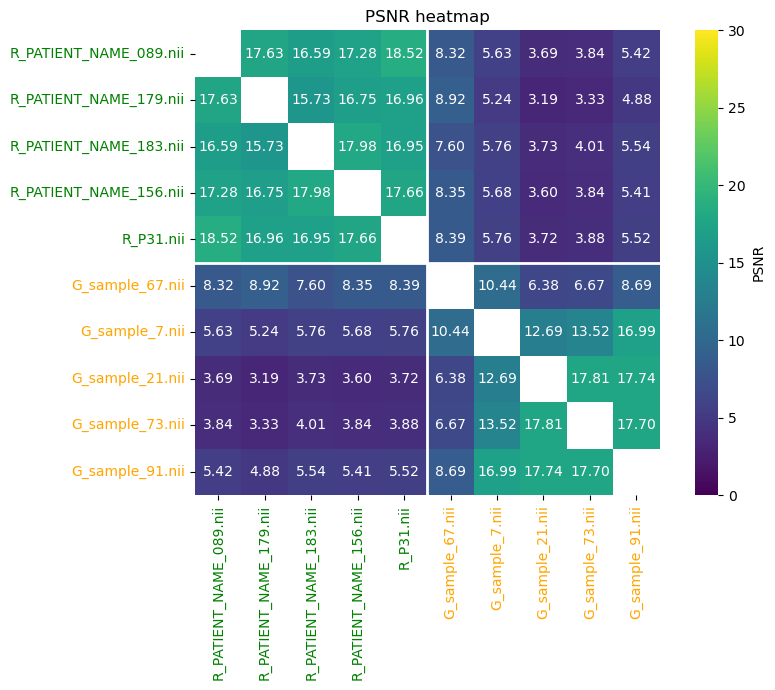

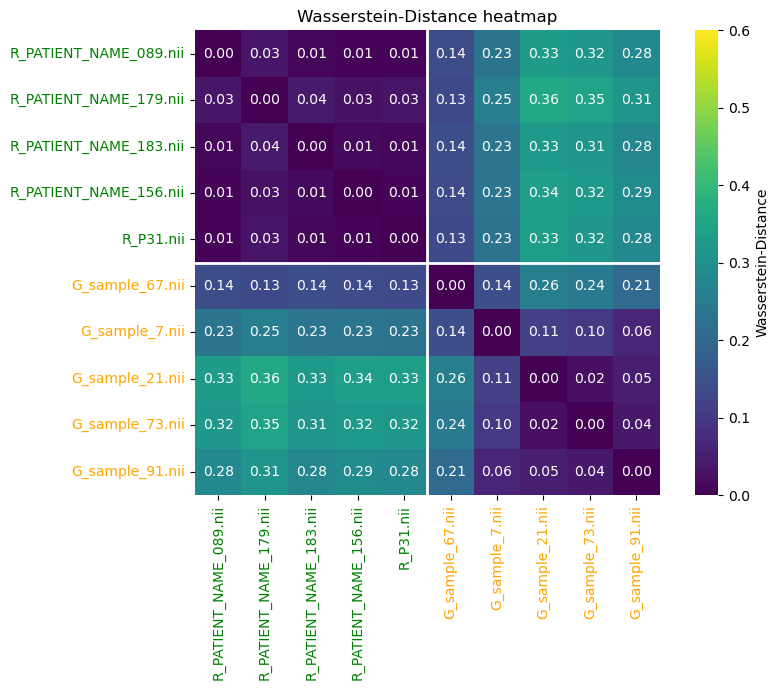

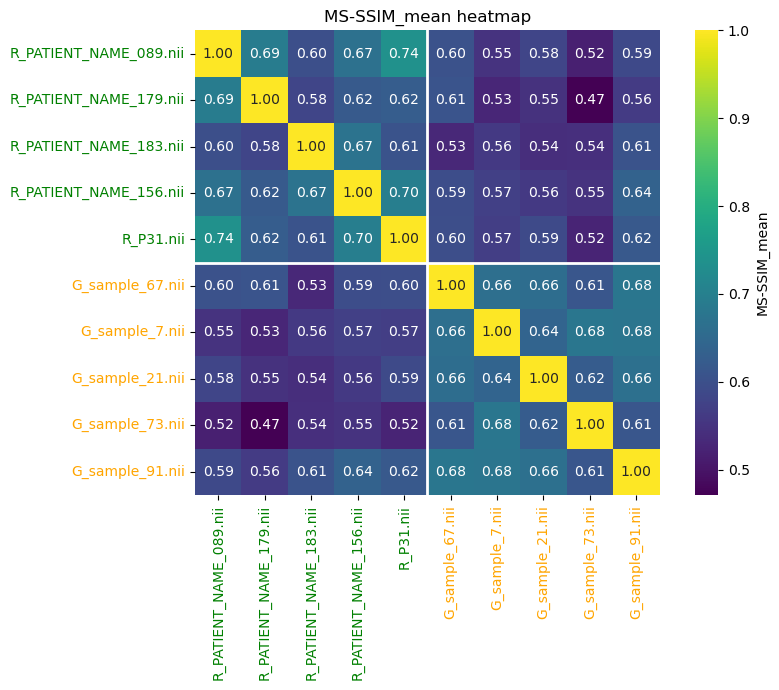

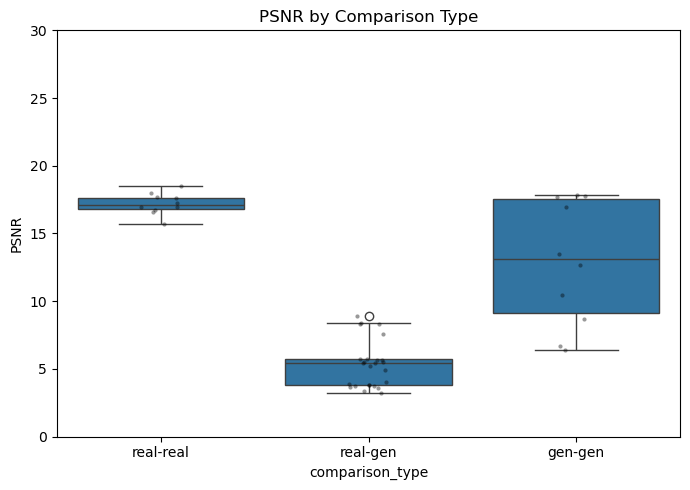

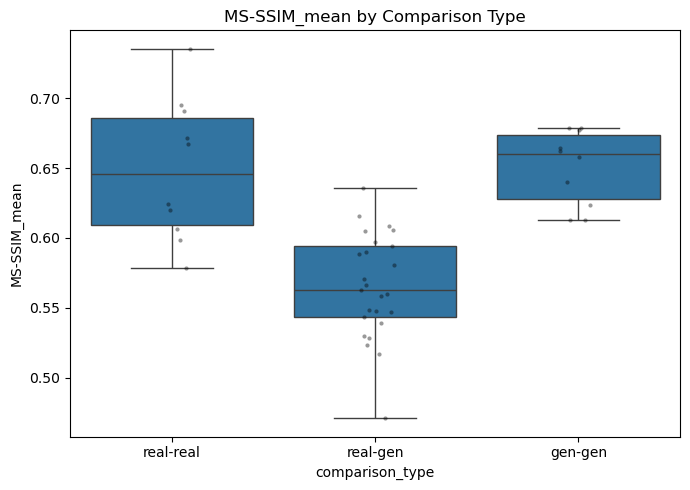

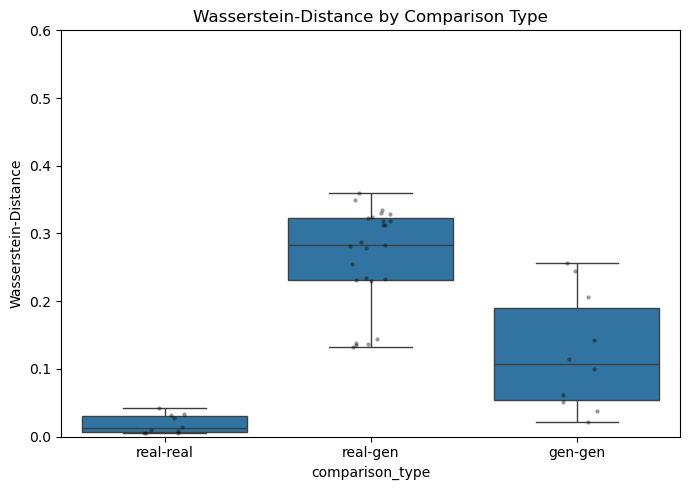

In [70]:
from pathlib import Path
import random


real_paths = sorted(
    glob.glob(
        "/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/*.nii.gz"
    )
)

# #good ones
# gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_10.nii.gz", 
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_20.nii.gz",
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_95.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_7.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_11.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_13.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_14.nii.gz"]

# #bad ones
# gen_paths = [
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_4.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_5.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_9.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_12.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_15.nii.gz",
#             ]

gen_paths = sorted(
    glob.glob(
        "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_*.nii.gz"
    )
)

real_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=True,
    )
    for p in real_paths
]

gen_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=False,
    )
    for p in gen_paths
]

#volumes = real_volumes[0:2] + gen_volumes[0:2]
#volumes = random.sample(real_volumes, 5) +  gen_volumes
volumes = random.sample(real_volumes, 5) +  random.sample(gen_volumes, 5)


compare_imgs = CompareMedicalImages(volumes, do_preprocessing=True, 
                                    spatial_size=(512, 512, 32),
                                    win_lev=60,
                                    win_wid=400,)
compare_imgs.compute_image_similarity_metrics()
compare_imgs.plot_heatmap("PSNR", vmin=0, vmax=30)
compare_imgs.plot_heatmap("Wasserstein-Distance", vmin=0, vmax=0.6)
compare_imgs.plot_heatmap("MS-SSIM_mean")
#compare_imgs.plot_pair_plots_hist()


compare_imgs.plot_metric_boxplot(
    metric_name="PSNR",
    groupby="comparison_type",
    ylim=(0, 30),
)

compare_imgs.plot_metric_boxplot(
    metric_name="MS-SSIM_mean",
    groupby="comparison_type",
)
compare_imgs.plot_metric_boxplot(
    metric_name="Wasserstein-Distance",
    groupby="comparison_type",
    ylim=(0, 0.6),
)



# BAD ONES - typu artefacts

# OUTLIERS

skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real-real skipped
skip comparison type real

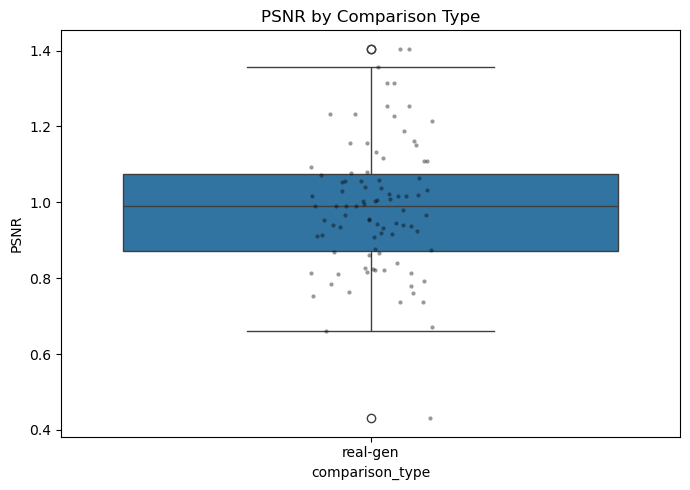

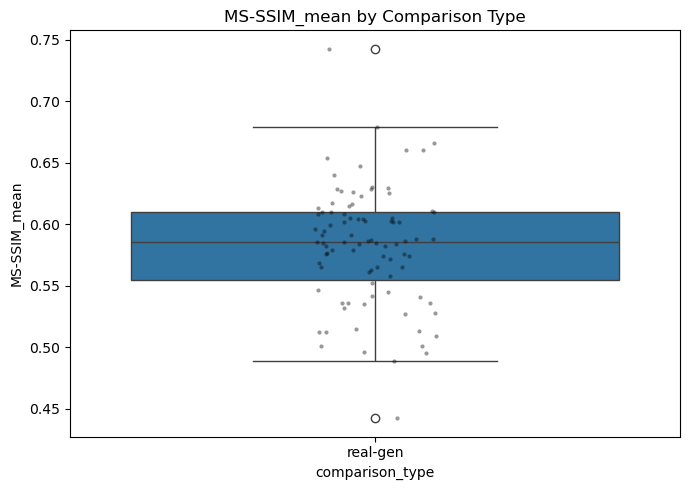

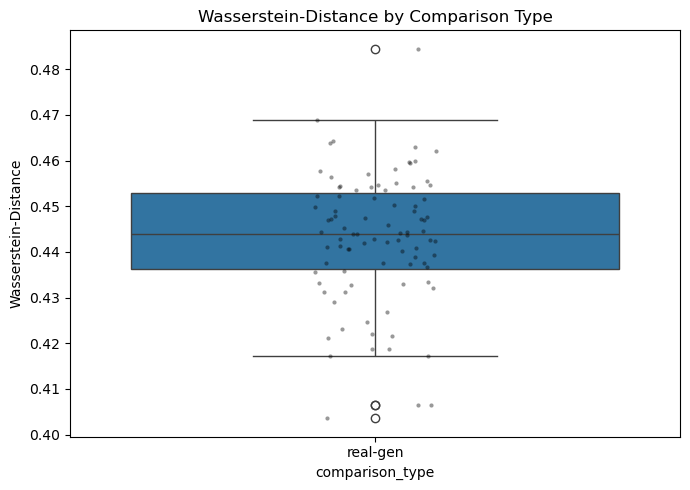

In [30]:
from pathlib import Path
import random


real_paths = sorted(
    glob.glob(
        "/ravana/d3d_work/common/DATA_med_img/augm/images_all/data_v2_prostate_32slices_34_plus_63/*.nii.gz"
    )
)

# #good ones
# gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_10.nii.gz", 
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_20.nii.gz",
#              "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_95.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_7.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_11.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_13.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_14.nii.gz"]

# #bad ones
# gen_paths = [
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_4.nii.gz",    
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_5.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_9.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_12.nii.gz",
#             "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_15.nii.gz",
#             ]

# gen_paths = sorted(
#     glob.glob(
#         "/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default_but_more/sample_*.nii.gz"
#     )
# )

gen_paths = ["/home/kamkal/diffusion-ct/augm/DM/diff_model_gen/ct_512_data_134_4399/default/sample_11.nii.gz"]

real_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=True,
    )
    for p in real_paths
]

gen_volumes = [
    VolumeInfo(
        path=p,
        patient_id=Path(p).stem,
        is_real=False,
    )
    for p in gen_paths
]

#volumes = real_volumes[0:2] + gen_volumes[0:2]
#volumes = random.sample(real_volumes, 5) +  gen_volumes
volumes = real_volumes +  gen_volumes


compare_imgs = CompareMedicalImages(volumes, do_preprocessing=True, 
                                    spatial_size=(512, 512, 32),
                                    win_lev=60,
                                    win_wid=400,)
compare_imgs.compute_image_similarity_metrics(skip_comparison_types=["real-real", "gen-gen"])
# compare_imgs.plot_heatmap("PSNR")
# compare_imgs.plot_heatmap("Wasserstein-Distance")
# compare_imgs.plot_heatmap("MS-SSIM_mean")
#compare_imgs.plot_pair_plots_hist()


compare_imgs.plot_metric_boxplot(
    metric_name="PSNR",
    groupby="comparison_type",
)

compare_imgs.plot_metric_boxplot(
    metric_name="MS-SSIM_mean",
    groupby="comparison_type",
)
compare_imgs.plot_metric_boxplot(
    metric_name="Wasserstein-Distance",
    groupby="comparison_type",
)

compare_imgs.results_to_dataframe().to_csv("image_similarity_metrics_1genvs_all_real.csv", index=False)

<Axes: >

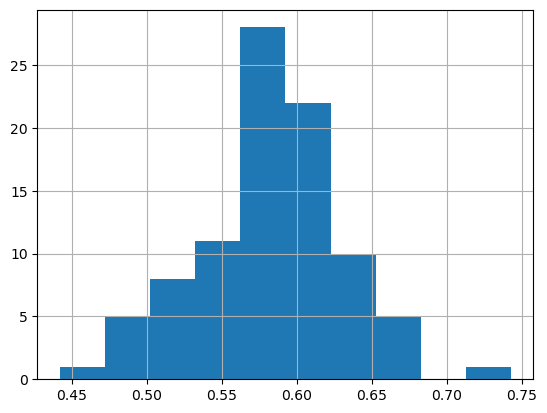

In [ ]:
# histogram z df
df = compare_imgs.results_to_dataframe()
df[df["comparison_type"] == "real-gen"]["MS-SSIM_mean"].hist(bins=20)

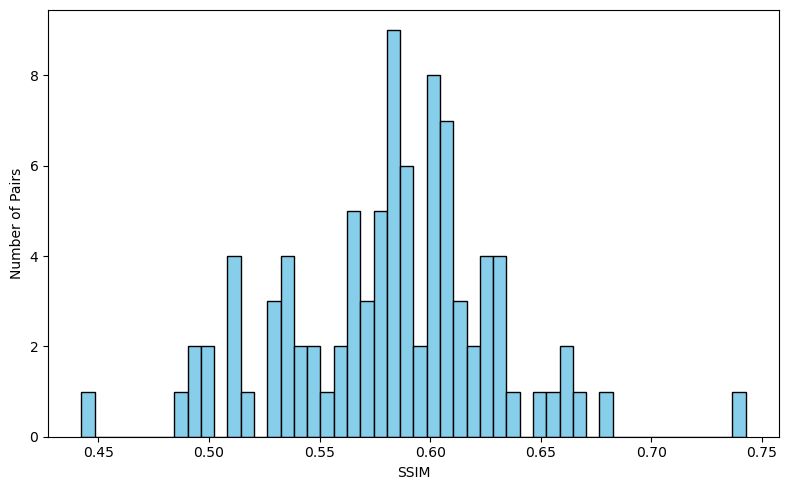

In [58]:
import matplotlib.pyplot as plt

df_real_gen = df[df["comparison_type"] == "real-gen"]

plt.figure(figsize=(8,5))
plt.hist(df_real_gen["MS-SSIM_mean"], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("SSIM")        # X-axis: metric name, formal but readable
plt.ylabel("Number of Pairs")              # Y-axis: counts
#plt.title("Distribution of SSIM for Real–Generated Image Pairs")  # descriptive title
plt.tight_layout()
plt.show()

In [36]:
filtered = df[df["MS-SSIM_mean"] > 0.70]
pairs = list(zip(filtered["i_path_short"], filtered["j_path_short"]))
for i_path, j_path in pairs:
    print(i_path, "<->", j_path)

PATIENT_NAME_151.nii.gz <-> sample_11.nii.gz


In [42]:
filtered = df[df["MS-SSIM_mean"] < 0.45]
pairs = list(zip(filtered["i_path_short"], filtered["j_path_short"]))
for i_path, j_path in pairs:
    print(i_path, "<->", j_path)

PATIENT_NAME_126.nii.gz <-> sample_11.nii.gz


In [37]:
filtered_wd = df[df["Wasserstein-Distance"] < 0.41]
pairs_wd = list(zip(filtered_wd["i_path_short"], filtered_wd["j_path_short"]))
for i_path, j_path in pairs_wd:
    print(i_path, "<->", j_path)

P17.nii.gz <-> sample_11.nii.gz
P5.nii.gz <-> sample_11.nii.gz
PATIENT_NAME_126.nii.gz <-> sample_11.nii.gz


In [38]:
# filtrujemy PSNR > 1.4
filtered_psnr = df[df["PSNR"] > 1.4]
pairs_psnr = list(zip(filtered_psnr["i_path_short"], filtered_psnr["j_path_short"]))
for i_path, j_path in pairs_psnr:
    print(i_path, "<->", j_path)

P17.nii.gz <-> sample_11.nii.gz
P5.nii.gz <-> sample_11.nii.gz
